## SETUP

In [ ]:
import os
import pandas as pd
import re

SAVE_PATH = "./data"

# Dataset
DATASET_FILENAME = "Indo_FreeNutritiousMeals_Sentiment_X_2025.csv"
DATASET_FILE_PATH = os.path.join(SAVE_PATH, DATASET_FILENAME)

if os.path.exists(DATASET_FILE_PATH):
    print(f"File sudah ada, skip download: {DATASET_FILE_PATH}")
else:
    from huggingface_hub import hf_hub_download
    
    os.makedirs(SAVE_PATH, exist_ok=True)
    
    path_to_file = hf_hub_download(
        repo_id="tasyapndya/free_nutritious_meals_sentiment_x_id_2025",
        filename=DATASET_FILENAME,
        repo_type="dataset",
        local_dir=SAVE_PATH,
        local_dir_use_symlinks=False,
    )
    
    print(f"Selesai! File tersimpan di: {path_to_file}")

# Slang Dictionary
SLANG_FILENAME = "colloquial-indonesian-lexicon.csv"
SLANG_FILE_PATH = os.path.join(SAVE_PATH, SLANG_FILENAME)

SLANG_URL = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"

if os.path.exists(SLANG_FILE_PATH):
    print(f"Slang dictionary sudah ada, skip download")
else:
    print("Sedang mendownload slang dictionary...")
    import urllib.request

    urllib.request.urlretrieve(SLANG_URL, SLANG_FILE_PATH)

    print(f"Selesai! Slang dictionary tersimpan di: {SLANG_FILE_PATH}")

# Indonesian Dictionary
WORDS_FILENAME = "kata-dasar.txt"
WORDS_FILE_PATH = os.path.join(SAVE_PATH, WORDS_FILENAME)

WORDS_URL = "https://raw.githubusercontent.com/har07/PySastrawi/master/src/Sastrawi/Stemmer/data/kata-dasar.txt"

if os.path.exists(WORDS_FILE_PATH):
    print(f"Dataset kata bahasa indonesia sudah ada, skip download")

else:
    print("Sedang mendownload dataset kata bahasa Indonesia")
    import urllib.request

    urllib.request.urlretrieve(WORDS_URL, WORDS_FILE_PATH)

    print(f"Selesai, Dataset kata bahasa indonesia tersimpan di {WORDS_FILE_PATH}")

File sudah ada, skip download: ./data\Indo_FreeNutritiousMeals_Sentiment_X_2025.csv


In [ ]:
df = pd.read_csv(DATASET_FILE_PATH)
print(f"Dataset dimuat: {df.shape[0]:,} baris, {df.shape[1]} kolom")
df.head()

## EDA

Preview Top 15

In [2]:
pd.set_option('display.max_colwidth', None)

df = pd.read_csv("data/Indo_FreeNutritiousMeals_Sentiment_X_2025.csv")
df.head(5).style.set_properties(**{'text-align': 'left'})

,cleaned_text,label
0,dari kementrian keuangan ke badan gizi nasional mana cair itu duit tanpa perintah prabowo mana ada makan beracun gratis ehh salah maksudnya makan bergizi gratis tanpa program yg digagas prabowo pejabat atas nama pemerintah menggunakan,negatif
1,koq ada bakteri e coli itu biasanya byk dikotoran manusia apa jgn2 makan bergizi gratis itu dicampur dgn,negatif
2,program makan bergizi gratis makin keren karena gerakan nyata bgn fokus ke distribusi makanan yang aman dan mutu terjamin,positif
3,no makan bergizi gratis yang bermasalah mitra mbg tersebut sudah diberikan sanksi dan ditutup lanjutkan mbg,netral
4,dukung program makan bergizi gratis,positif


Missing Values

In [ ]:
missing_values = df.isna().sum()
print(f"Jumlah missing values: {missing_values}")

Jumlah missing values: cleaned_text    0
label           2
dtype: int64


In [ ]:
df = df.dropna(subset=['label'])
missing_values = df.isna().sum()
print(f"Jumlah missing values: {missing_values}")

Jumlah missing values: cleaned_text    0
label           0
dtype: int64


Duplicates

In [ ]:
num_duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {num_duplicates}")

Jumlah baris duplikat: 0


Label Distribution

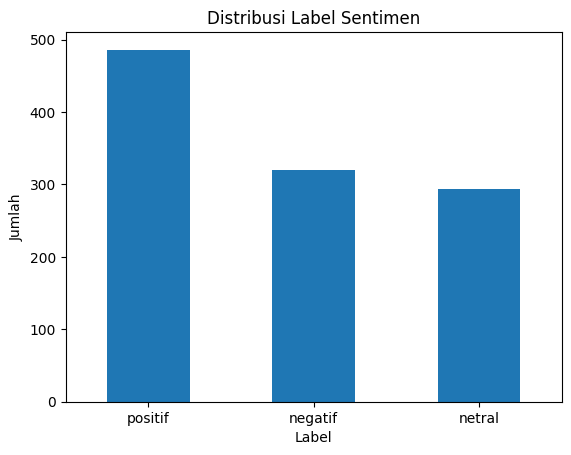

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Distribusi Label Sentimen")
plt.xlabel("Label")
plt.xticks(rotation=0)
plt.ylabel("Jumlah")
plt.show()